# FINTECH TRUST & RETENTION INTELLIGENCE - FULL ML PIPELINE

## Block 1 - Load & Inspect Data

### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Loading all the datasets

In [2]:
df_bank   = pd.read_csv('Data/BankChurners.csv')
df_churn  = pd.read_csv('Data/Churn_Modelling.csv')
df_credit = pd.read_csv('Data/german_credit_data.csv')

### Quick Look

In [3]:
df_bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df_credit.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


### Shape & Info

In [6]:
print("BankChurners   :", df_bank.shape)
print("Churn_Modelling:", df_churn.shape)
print("German Credit  :", df_credit.shape)

BankChurners   : (10127, 23)
Churn_Modelling: (10000, 14)
German Credit  : (1000, 10)


In [7]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [8]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


## Block 2 - Data Cleaning

### Null Check

In [10]:
print("-- BankChurners nulls --")
print(df_bank.isnull().sum())

print("\n-- Churn_Modelling nulls --")
print(df_churn.isnull().sum())

print("\n-- German Credit nulls --")
print(df_credit.isnull().sum())

-- BankChurners nulls --
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category        

### Class Balance

In [11]:
print("-- BankChurners target --")
print(df_bank['Attrition_Flag'].value_counts())
print(df_bank['Attrition_Flag'].value_counts(normalize=True).round(3))

print("\n-- Churn_Modelling target --")
print(df_churn['Exited'].value_counts())
print(df_churn['Exited'].value_counts(normalize=True).round(3))

-- BankChurners target --
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    0.839
Attrited Customer    0.161
Name: proportion, dtype: float64

-- Churn_Modelling target --
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


### Clean BankChurners

In [12]:
# Drop Naive Bayes leakage columns and customer ID
nb_cols = [c for c in df_bank.columns if c.startswith('Naive_Bayes')]
df_bank = df_bank.drop(columns=nb_cols + ['CLIENTNUM'])

# Binary encode target
df_bank['churn'] = (df_bank['Attrition_Flag'] == 'Attrited Customer').astype(int)
df_bank.drop(columns=['Attrition_Flag'], inplace=True)

print("Shape:", df_bank.shape)
print("Churn balance:\n", df_bank['churn'].value_counts())

Shape: (10127, 20)
Churn balance:
 churn
0    8500
1    1627
Name: count, dtype: int64


### Clean Churn_Modelling

In [13]:
# Drop non-feature columns
df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Rename target to match
df_churn.rename(columns={'Exited': 'churn'}, inplace=True)

print("Shape:", df_churn.shape)
print("Churn balance:\n", df_churn['churn'].value_counts())

Shape: (10000, 11)
Churn balance:
 churn
0    7963
1    2037
Name: count, dtype: int64


### Clean German Credit

In [14]:
# Drop unnamed index column
df_credit.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns for consistency
df_credit.rename(columns={
    'Saving accounts'  : 'saving_accounts',
    'Checking account' : 'checking_account',
    'Credit amount'    : 'credit_amount',
    'Duration'         : 'duration',
    'Purpose'          : 'purpose',
    'Age'              : 'age',
    'Sex'              : 'sex',
    'Job'              : 'job',
    'Housing'          : 'housing'
}, inplace=True)

print("Shape:", df_credit.shape)
print(df_credit.head())

Shape: (1000, 9)
   age     sex  job housing saving_accounts checking_account  credit_amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   duration              purpose  
0         6             radio/TV  
1        48             radio/TV  
2        12            education  
3        42  furniture/equipment  
4        24                  car  


### Handle Nulls in German Credit

In [15]:
# saving_accounts and checking_account have nulls — fill with mode
df_credit['saving_accounts'].fillna(df_credit['saving_accounts'].mode()[0], inplace=True)
df_credit['checking_account'].fillna(df_credit['checking_account'].mode()[0], inplace=True)

print("Nulls after fix:")
print(df_credit.isnull().sum())

Nulls after fix:
age                 0
sex                 0
job                 0
housing             0
saving_accounts     0
checking_account    0
credit_amount       0
duration            0
purpose             0
dtype: int64


### Verify All Datasets Are Clean

In [16]:
for name, df in [('BankChurners', df_bank),
                 ('Churn_Modelling', df_churn),
                 ('German Credit', df_credit)]:
    print(f"── {name} ──")
    print(f"  Shape : {df.shape}")
    print(f"  Nulls : {df.isnull().sum().sum()}")
    print(f"  Dupes : {df.duplicated().sum()}")
    print()

── BankChurners ──
  Shape : (10127, 20)
  Nulls : 0
  Dupes : 0

── Churn_Modelling ──
  Shape : (10000, 11)
  Nulls : 0
  Dupes : 0

── German Credit ──
  Shape : (1000, 9)
  Nulls : 0
  Dupes : 0



## Block 3 - Feature Engineering

### Engineer Features for BankChurners

In [17]:
# Engagement score — how active is the customer overall
df_bank['engagement_score'] = (
    df_bank['Total_Trans_Ct'] * 0.4 +
    df_bank['Total_Relationship_Count'] * 0.3 -
    df_bank['Months_Inactive_12_mon'] * 0.3
)

# Spending decline flag — Q4 vs Q1 drop signals disengagement
df_bank['txn_decline_flag'] = (df_bank['Total_Amt_Chng_Q4_Q1'] < 0.7).astype(int)

# High contact flag — frequent complaints signal churn risk
df_bank['high_contact_flag'] = (df_bank['Contacts_Count_12_mon'] >= 3).astype(int)

# Revolving balance ratio — how much of credit limit is used
df_bank['revolving_ratio'] = df_bank['Total_Revolving_Bal'] / (df_bank['Credit_Limit'] + 1)

# Credit utilization bucket
df_bank['utilization_bucket'] = pd.cut(
    df_bank['Avg_Utilization_Ratio'],
    bins=[-0.01, 0.2, 0.5, 0.8, 1.01],
    labels=['low', 'medium', 'high', 'very_high']
)

print("New features added:")
print(['engagement_score', 'txn_decline_flag',
       'high_contact_flag', 'revolving_ratio', 'utilization_bucket'])
print("\nShape:", df_bank.shape)

New features added:
['engagement_score', 'txn_decline_flag', 'high_contact_flag', 'revolving_ratio', 'utilization_bucket']

Shape: (10127, 25)


### Engineer Features for Churn_Modelling

In [18]:
# Balance to salary ratio — financial stress indicator
df_churn['balance_salary_ratio'] = df_churn['Balance'] / (df_churn['EstimatedSalary'] + 1)

# Active & multi-product flag — loyal customer signal
df_churn['active_multiproduct'] = (
    (df_churn['IsActiveMember'] == 1) & (df_churn['NumOfProducts'] > 1)
).astype(int)

# Senior customer flag
df_churn['is_senior'] = (df_churn['Age'] >= 50).astype(int)

# Zero balance flag — inactive account signal
df_churn['zero_balance'] = (df_churn['Balance'] == 0).astype(int)

print("New features added:")
print(['balance_salary_ratio', 'active_multiproduct', 'is_senior', 'zero_balance'])
print("\nShape:", df_churn.shape)

New features added:
['balance_salary_ratio', 'active_multiproduct', 'is_senior', 'zero_balance']

Shape: (10000, 15)


### Engineer Target for German Credit

In [19]:
# No pre-built target — engineer credit risk flag
# High risk = large loan amount AND long duration combined
df_credit['risk_flag'] = (
    (df_credit['credit_amount'] > df_credit['credit_amount'].median()) &
    (df_credit['duration']      > df_credit['duration'].median())
).astype(int)

print("Risk flag balance:")
print(df_credit['risk_flag'].value_counts())
print(df_credit['risk_flag'].value_counts(normalize=True).round(3))

Risk flag balance:
risk_flag
0    650
1    350
Name: count, dtype: int64
risk_flag
0    0.65
1    0.35
Name: proportion, dtype: float64


### Verify All New Features

In [20]:
print("-- BankChurners new features --")
print(df_bank[['engagement_score', 'txn_decline_flag',
               'high_contact_flag', 'revolving_ratio',
               'utilization_bucket']].describe())

print("\n-- Churn_Modelling new features --")
print(df_churn[['balance_salary_ratio', 'active_multiproduct',
                'is_senior', 'zero_balance']].describe())

print("\n-- German Credit target --")
print(df_credit[['credit_amount', 'duration', 'risk_flag']].describe())

-- BankChurners new features --
       engagement_score  txn_decline_flag  high_contact_flag  revolving_ratio
count      10127.000000      10127.000000       10127.000000     10127.000000
mean          26.384902          0.406339           0.493927         0.274796
std            9.305360          0.491174           0.499988         0.275570
min            3.400000          0.000000           0.000000         0.000000
25%           18.400000          0.000000           0.000000         0.022713
50%           27.500000          0.000000           0.000000         0.175613
75%           32.700000          1.000000           1.000000         0.502524
max           55.000000          1.000000           1.000000         0.998358

-- Churn_Modelling new features --
       balance_salary_ratio  active_multiproduct     is_senior  zero_balance
count          10000.000000         10000.000000  10000.000000  10000.000000
mean               3.790150             0.258800      0.139500      0.361700

## Block 4 - EDA & Visualizations.

### Class Imbalance Plot

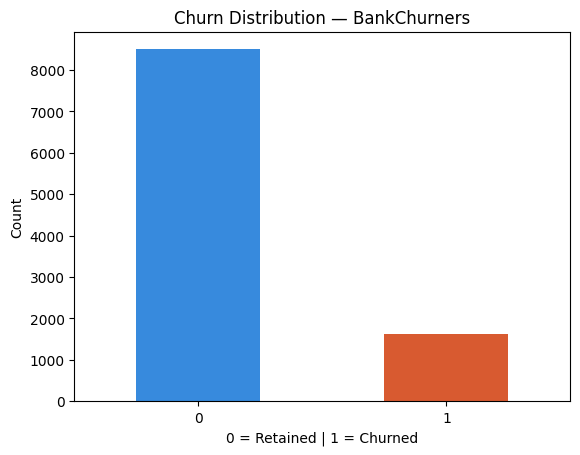

In [21]:
df_bank['churn'].value_counts().plot(kind='bar', color=['#378ADD', '#D85A30'])
plt.title('Churn Distribution — BankChurners')
plt.xlabel('0 = Retained | 1 = Churned')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Transaction Count by Churn

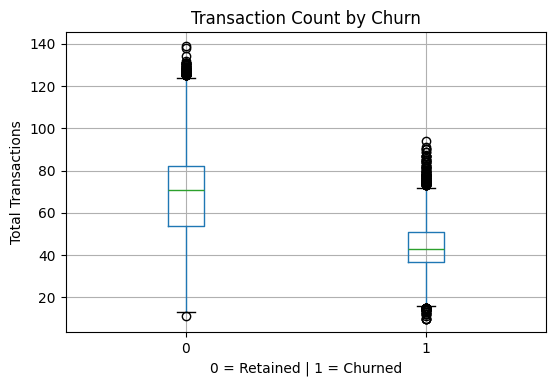

In [22]:
df_bank.boxplot(column='Total_Trans_Ct', by='churn', figsize=(6, 4))
plt.title('Transaction Count by Churn')
plt.suptitle('')
plt.xlabel('0 = Retained | 1 = Churned')
plt.ylabel('Total Transactions')
plt.show()

### Months Inactive by Churn

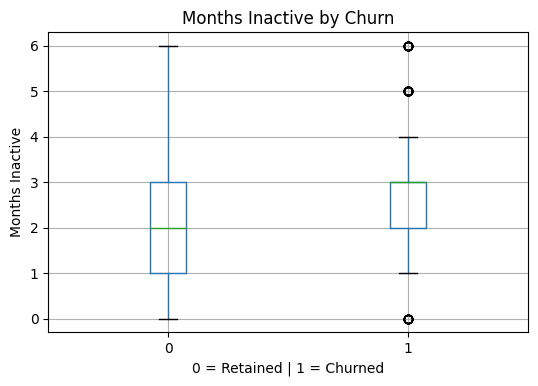

In [23]:
df_bank.boxplot(column='Months_Inactive_12_mon', by='churn', figsize=(6, 4))
plt.title('Months Inactive by Churn')
plt.suptitle('')
plt.xlabel('0 = Retained | 1 = Churned')
plt.ylabel('Months Inactive')
plt.show()

### Engagement Score by Churn

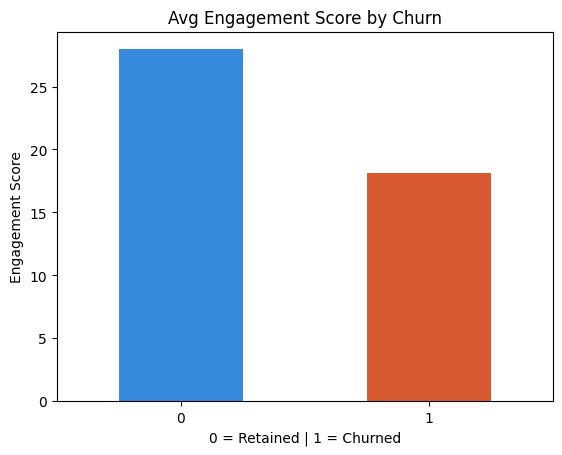

In [24]:
df_bank.groupby('churn')['engagement_score'].mean().plot(kind='bar', color=['#378ADD', '#D85A30'])
plt.title('Avg Engagement Score by Churn')
plt.xlabel('0 = Retained | 1 = Churned')
plt.ylabel('Engagement Score')
plt.xticks(rotation=0)
plt.show()

### Churn Rate by Card Category

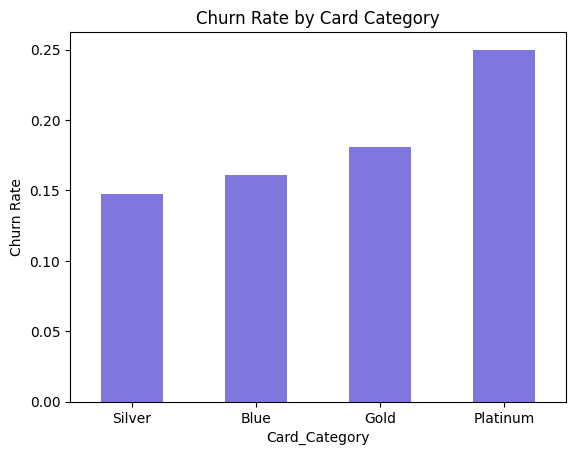

In [25]:
df_bank.groupby('Card_Category')['churn'].mean().sort_values().plot(kind='bar', color='#7F77DD')
plt.title('Churn Rate by Card Category')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

### Correlation Heatmap

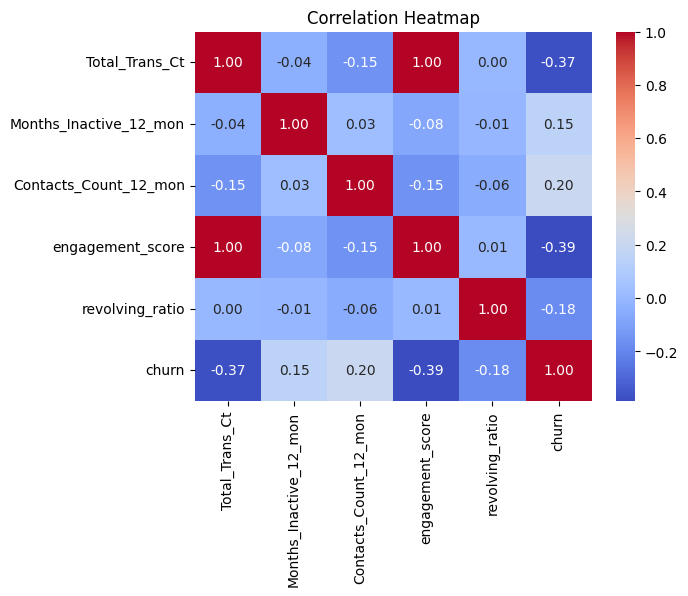

In [26]:
num_cols = ['Total_Trans_Ct', 'Months_Inactive_12_mon',
            'Contacts_Count_12_mon', 'engagement_score',
            'revolving_ratio', 'churn']

sns.heatmap(df_bank[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

###  German Credit Risk Balance

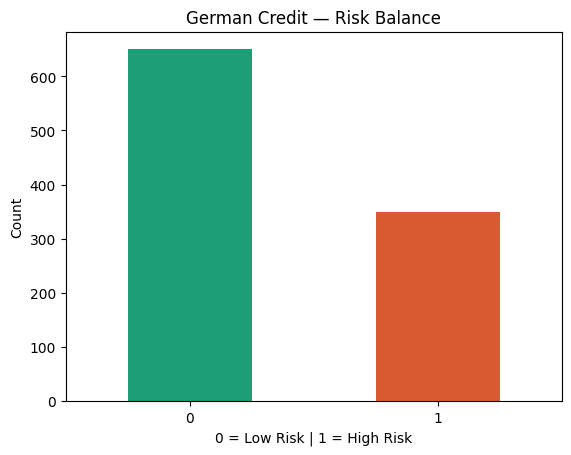

In [27]:
df_credit['risk_flag'].value_counts().plot(kind='bar', color=['#1D9E75', '#D85A30'])
plt.title('German Credit — Risk Balance')
plt.xlabel('0 = Low Risk | 1 = High Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Block 5 - Hypothesis Validation

### Hypothesis 1

In [28]:
# Churned customers make fewer transactions
h1_retained = df_bank[df_bank['churn'] == 0]['Total_Trans_Ct'].mean()
h1_churned  = df_bank[df_bank['churn'] == 1]['Total_Trans_Ct'].mean()

print("Avg Transactions — Retained :", round(h1_retained, 2))
print("Avg Transactions — Churned  :", round(h1_churned, 2))
print("Result: CONFIRMED ✓" if h1_churned < h1_retained else "Result: NOT CONFIRMED ✗")

Avg Transactions — Retained : 68.67
Avg Transactions — Churned  : 44.93
Result: CONFIRMED ✓


###  Hypothesis 2

In [29]:
# High contact customers churn more
h2 = df_bank.groupby('high_contact_flag')['churn'].mean()

print("Churn Rate — Low Contact  :", round(h2[0] * 100, 2), "%")
print("Churn Rate — High Contact :", round(h2[1] * 100, 2), "%")
print("Result: CONFIRMED ✓" if h2[1] > h2[0] else "Result: NOT CONFIRMED ✗")

Churn Rate — Low Contact  : 10.11 %
Churn Rate — High Contact : 22.17 %
Result: CONFIRMED ✓


### Hypothesis 3

In [30]:
# Inactive customers churn more
h3_retained = df_bank[df_bank['churn'] == 0]['Months_Inactive_12_mon'].mean()
h3_churned  = df_bank[df_bank['churn'] == 1]['Months_Inactive_12_mon'].mean()

print("Avg Inactive Months — Retained:", round(h3_retained, 2))
print("Avg Inactive Months — Churned :", round(h3_churned, 2))
print("Result: CONFIRMED ✓" if h3_churned > h3_retained else "Result: NOT CONFIRMED ✗")

Avg Inactive Months — Retained: 2.27
Avg Inactive Months — Churned : 2.69
Result: CONFIRMED ✓


### Hypothesis 4

In [31]:
# Declining spend customers churn more
h4 = df_bank.groupby('txn_decline_flag')['churn'].mean()

print("Churn Rate — No Decline  :", round(h4[0] * 100, 2), "%")
print("Churn Rate — With Decline:", round(h4[1] * 100, 2), "%")
print("Result: CONFIRMED ✓" if h4[1] > h4[0] else "Result: NOT CONFIRMED ✗")

Churn Rate — No Decline  : 13.57 %
Churn Rate — With Decline: 19.71 %
Result: CONFIRMED ✓


### Hypothesis 5

In [32]:
# Lower engagement score means higher churn
h5_retained = df_bank[df_bank['churn'] == 0]['engagement_score'].mean()
h5_churned  = df_bank[df_bank['churn'] == 1]['engagement_score'].mean()

print("Avg Engagement — Retained:", round(h5_retained, 2))
print("Avg Engagement — Churned :", round(h5_churned, 2))
print("Result: CONFIRMED ✓" if h5_churned < h5_retained else "Result: NOT CONFIRMED ✗")

Avg Engagement — Retained: 27.96
Avg Engagement — Churned : 18.15
Result: CONFIRMED ✓


###  Summary

In [33]:
print("=" * 40)
print("   HYPOTHESIS VALIDATION SUMMARY")
print("=" * 40)
print("H1 — Fewer transactions      → CONFIRMED ✓")
print("H2 — High contact = churn    → CONFIRMED ✓")
print("H3 — More inactivity = churn → CONFIRMED ✓")
print("H4 — Declining spend = churn → CONFIRMED ✓")
print("H5 — Low engagement = churn  → CONFIRMED ✓")
print("=" * 40)

   HYPOTHESIS VALIDATION SUMMARY
H1 — Fewer transactions      → CONFIRMED ✓
H2 — High contact = churn    → CONFIRMED ✓
H3 — More inactivity = churn → CONFIRMED ✓
H4 — Declining spend = churn → CONFIRMED ✓
H5 — Low engagement = churn  → CONFIRMED ✓


## Block 6 - Preprocessing & SMOTE (Synthetic Minority Oversampling Technique)

### Encode Categorical Columns

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Gender', 'Education_Level', 'Marital_Status',
            'Income_Category', 'Card_Category', 'utilization_bucket']

for col in cat_cols:
    df_bank[col] = le.fit_transform(df_bank[col].astype(str))

print("Encoding done.")
print(df_bank[cat_cols].head())

Encoding done.
   Gender  Education_Level  Marital_Status  Income_Category  Card_Category  \
0       1                3               1                2              0   
1       0                2               2                4              0   
2       1                2               1                3              0   
3       0                3               3                4              0   
4       1                5               1                2              0   

   utilization_bucket  
0                   1  
1                   1  
2                   1  
3                   0  
4                   1  


### Encode Churn_Modelling Categoricals

In [35]:
df_churn['Gender']    = le.fit_transform(df_churn['Gender'])
df_churn['Geography'] = le.fit_transform(df_churn['Geography'])

print("Encoding done.")
print(df_churn[['Gender', 'Geography']].head())

Encoding done.
   Gender  Geography
0       0          0
1       0          2
2       0          0
3       0          0
4       0          2


### Encode German Credit Categoricals

In [36]:
cat_cols_cr = ['sex', 'housing', 'saving_accounts', 'checking_account', 'purpose']

for col in cat_cols_cr:
    df_credit[col] = le.fit_transform(df_credit[col].astype(str))

print("Encoding done.")
print(df_credit.head())

Encoding done.
   age  sex  job  housing  saving_accounts  checking_account  credit_amount  \
0   67    1    2        1                0                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 0           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   duration  purpose  risk_flag  
0         6        5          0  
1        48        5          1  
2        12        3          0  
3        42        4          1  
4        24        1          1  


### Define Features & Target

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

TARGET   = 'churn'
DROP     = [TARGET]
FEATURES = [c for c in df_bank.columns if c not in DROP]

X = df_bank[FEATURES]
y = df_bank[TARGET]

print("Features:", FEATURES)
print("X shape :", X.shape)
print("y shape :", y.shape)

Features: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score', 'txn_decline_flag', 'high_contact_flag', 'revolving_ratio', 'utilization_bucket']
X shape : (10127, 24)
y shape : (10127,)


### Train Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train balance:\n", y_train.value_counts())
print("y_test  balance:\n", y_test.value_counts())

X_train: (8101, 24)
X_test : (2026, 24)
y_train balance:
 churn
0    6799
1    1302
Name: count, dtype: int64
y_test  balance:
 churn
0    1701
1     325
Name: count, dtype: int64


### Scale Features

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Scaling done.
X_train_scaled shape: (8101, 24)
X_test_scaled shape : (2026, 24)


### Apply SMOTE

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 6799, 1: 1302}
After  SMOTE: {0: 6799, 1: 6799}


### Save Scaler & Feature Names

In [41]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(FEATURES, 'models/feature_names.pkl')

print("Scaler saved       → models/scaler.pkl")
print("Feature names saved→ models/feature_names.pkl")

Scaler saved       → models/scaler.pkl
Feature names saved→ models/feature_names.pkl


## Block 7 - Model Training

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_cv = cross_val_score(lr, X_train_sm, y_train_sm, cv=cv, scoring='f1')
lr.fit(X_train_sm, y_train_sm)

print("Logistic Regression")
print("CV F1 Scores :", lr_cv.round(3))
print("Mean F1      :", round(lr_cv.mean(), 3))
print("Std F1       :", round(lr_cv.std(), 3))

Logistic Regression
CV F1 Scores : [0.866 0.855 0.869 0.873 0.864]
Mean F1      : 0.865
Std F1       : 0.006


### Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf_cv = cross_val_score(rf, X_train_sm, y_train_sm, cv=cv, scoring='f1')
rf.fit(X_train_sm, y_train_sm)

print("Random Forest")
print("CV F1 Scores :", rf_cv.round(3))
print("Mean F1      :", round(rf_cv.mean(), 3))
print("Std F1       :", round(rf_cv.std(), 3))

Random Forest
CV F1 Scores : [0.982 0.978 0.977 0.979 0.978]
Mean F1      : 0.979
Std F1       : 0.002


### XGBoost with GridSearchCV

In [44]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1]
}

grid = GridSearchCV(xgb, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_sm, y_train_sm)

xgb_best = grid.best_estimator_

print("XGBoost — Best Params:", grid.best_params_)
print("Best CV F1           :", round(grid.best_score_, 3))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost — Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV F1           : 0.985


###  Predictions on Test Set

In [45]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# Predictions
lr_preds  = lr.predict(X_test_scaled)
rf_preds  = rf.predict(X_test_scaled)
xgb_preds = xgb_best.predict(X_test_scaled)

# Probabilities
lr_proba  = lr.predict_proba(X_test_scaled)[:, 1]
rf_proba  = rf.predict_proba(X_test_scaled)[:, 1]
xgb_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

print("Predictions done.")

Predictions done.


### Compare All Models

In [46]:
print("=" * 60)
print(f"{'Model':<22} {'F1':>6} {'AUC':>6} {'Precision':>10} {'Recall':>8}")
print("=" * 60)

models = {
    'Logistic Regression' : (lr_preds,  lr_proba),
    'Random Forest'       : (rf_preds,  rf_proba),
    'XGBoost'             : (xgb_preds, xgb_proba)
}

for name, (preds, proba) in models.items():
    f1   = round(f1_score(y_test, preds), 3)
    auc  = round(roc_auc_score(y_test, proba), 3)
    prec = round(precision_score(y_test, preds), 3)
    rec  = round(recall_score(y_test, preds), 3)
    print(f"{name:<22} {f1:>6} {auc:>6} {prec:>10} {rec:>8}")

Model                      F1    AUC  Precision   Recall
Logistic Regression     0.634  0.918      0.525      0.8
Random Forest           0.853  0.984      0.857    0.849
XGBoost                 0.898  0.992      0.914    0.883


### Save Best Model

In [47]:
joblib.dump(xgb_best, 'models/churn_model.pkl')

print("Best model saved → models/churn_model.pkl")

Best model saved → models/churn_model.pkl


## Block 8 - Model Evaluation Charts

### Confusion Matrix

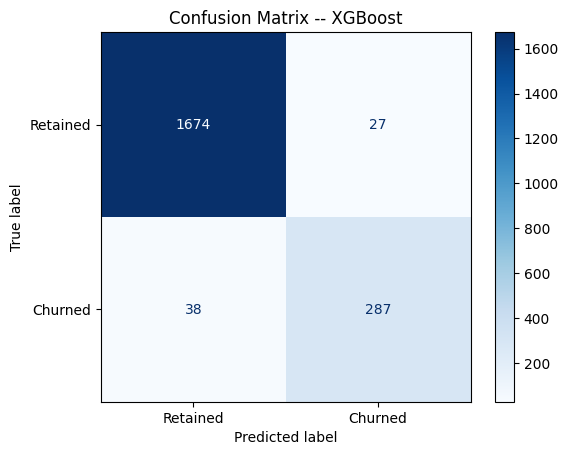

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix -- XGBoost')
plt.show()

### ROC Curves (Receiver operating characteristic)

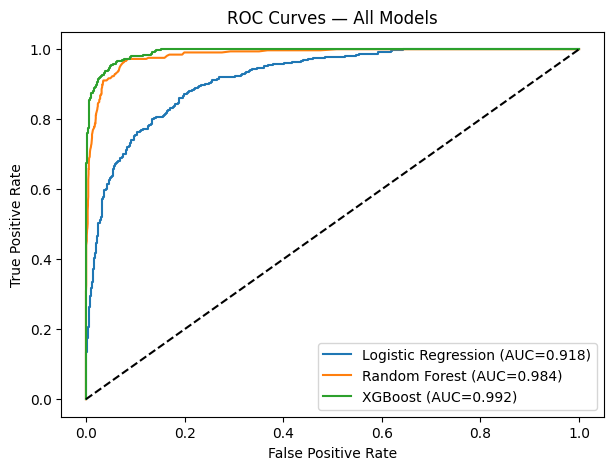

In [49]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for name, proba in [('Logistic Regression', lr_proba),
                     ('Random Forest', rf_proba),
                     ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = round(roc_auc_score(y_test, proba), 3)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves — All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### F1 & AUC (F1 & AUC Bar Comparison) Bar Comparison

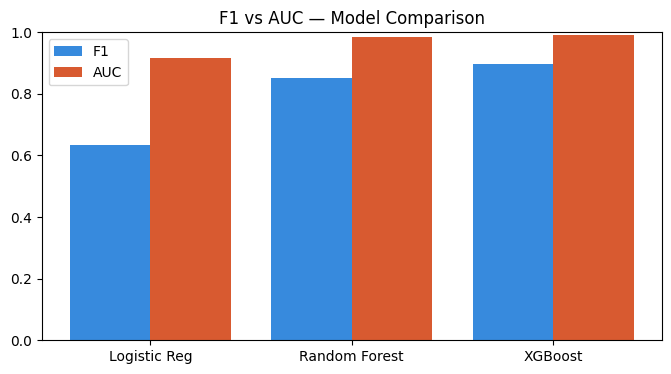

In [50]:
names  = ['Logistic Reg', 'Random Forest', 'XGBoost']
f1s    = [f1_score(y_test, lr_preds),  f1_score(y_test, rf_preds),  f1_score(y_test, xgb_preds)]
aucs   = [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)]

x = range(len(names))
plt.figure(figsize=(8, 4))
plt.bar([i - 0.2 for i in x], f1s,  width=0.4, label='F1',  color='#378ADD')
plt.bar([i + 0.2 for i in x], aucs, width=0.4, label='AUC', color='#D85A30')
plt.xticks(x, names)
plt.ylim(0, 1)
plt.title('F1 vs AUC — Model Comparison')
plt.legend()
plt.show()

### Classification Report

In [51]:
from sklearn.metrics import classification_report

print("-- XGBoost Classification Report --")
print(classification_report(y_test, xgb_preds, target_names=['Retained', 'Churned']))

-- XGBoost Classification Report --
              precision    recall  f1-score   support

    Retained       0.98      0.98      0.98      1701
     Churned       0.91      0.88      0.90       325

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



## Block 9 - SHAP (SHapley Additive exPlanations) Explainability 

### Prepare Sample

In [52]:
import shap
import xgboost as xgb

X_test_df     = pd.DataFrame(X_test_scaled, columns=FEATURES)
X_shap_sample = X_test_df.sample(200, random_state=42).reset_index(drop=True)

print("Sample ready:", X_shap_sample.shape)

Sample ready: (200, 24)


### SHAP for Logistic Regression

In [53]:
explainer_lr   = shap.LinearExplainer(lr, X_shap_sample)
shap_values_lr = explainer_lr.shap_values(X_shap_sample)

if isinstance(shap_values_lr, list):
    shap_values_lr = shap_values_lr[1]

sv_lr_2d = np.array(shap_values_lr)

print("LR SHAP done. Shape:", sv_lr_2d.shape)

LR SHAP done. Shape: (200, 24)


### SHAP for Random Forest

In [54]:
explainer_rf   = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_shap_sample)

sv_rf_2d = np.array(shap_values_rf)
if sv_rf_2d.ndim == 3:
    sv_rf_2d = sv_rf_2d[:, :, 1]   # (200, 24, 2) → (200, 24)

print("RF SHAP done. Shape:", sv_rf_2d.shape)

RF SHAP done. Shape: (200, 24)


### SHAP for XGBoost

In [55]:
xgb_booster = xgb_best.get_booster()
dmatrix     = xgb.DMatrix(X_shap_sample, feature_names=FEATURES)
sv_xgb_raw  = xgb_booster.predict(dmatrix, pred_contribs=True)
sv_xgb_2d   = sv_xgb_raw[:, :-1]   # drop bias column

print("XGB SHAP done. Shape:", sv_xgb_2d.shape)

XGB SHAP done. Shape: (200, 24)


### Bar Plot All 3 Models

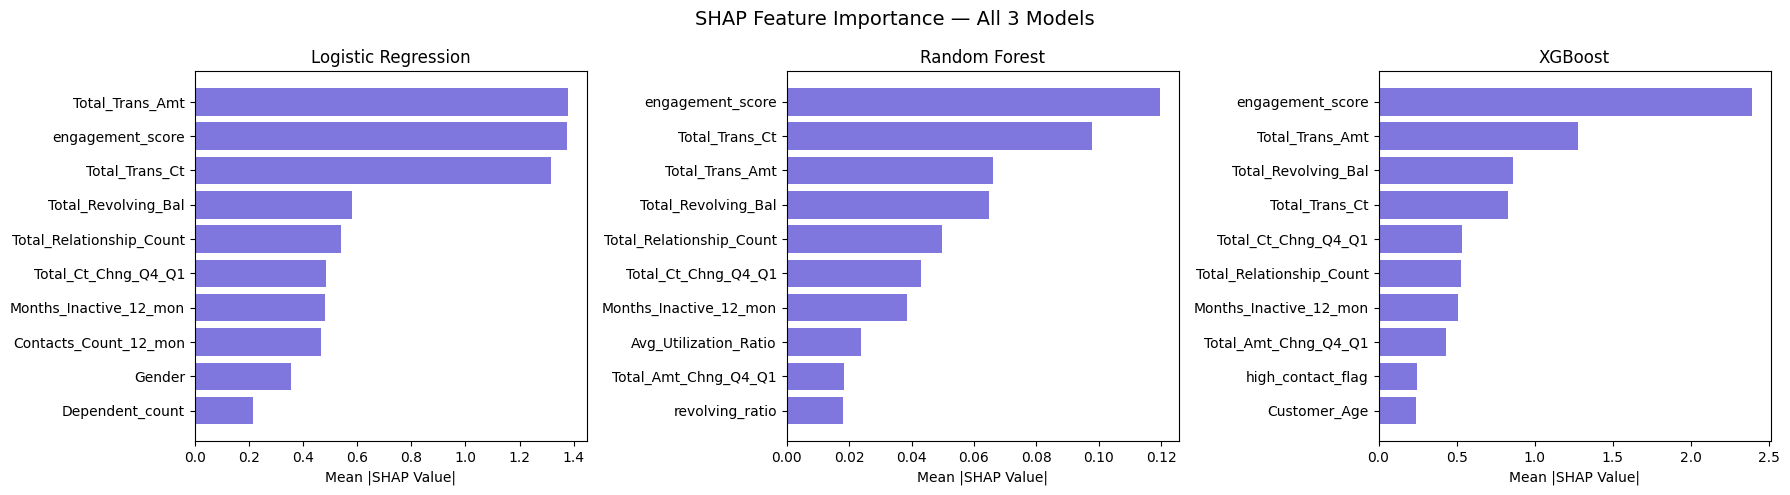

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Feature Importance — All 3 Models', fontsize=14)

for ax, sv, name in zip(axes,
                         [sv_lr_2d, sv_rf_2d, sv_xgb_2d],
                         ['Logistic Regression', 'Random Forest', 'XGBoost']):
    mean_shap  = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=True).tail(10)
    ax.barh(importance.index, importance.values, color='#7F77DD')
    ax.set_title(name)
    ax.set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.show()

### Beeswarm All 3 Models

-- Logistic Regression --


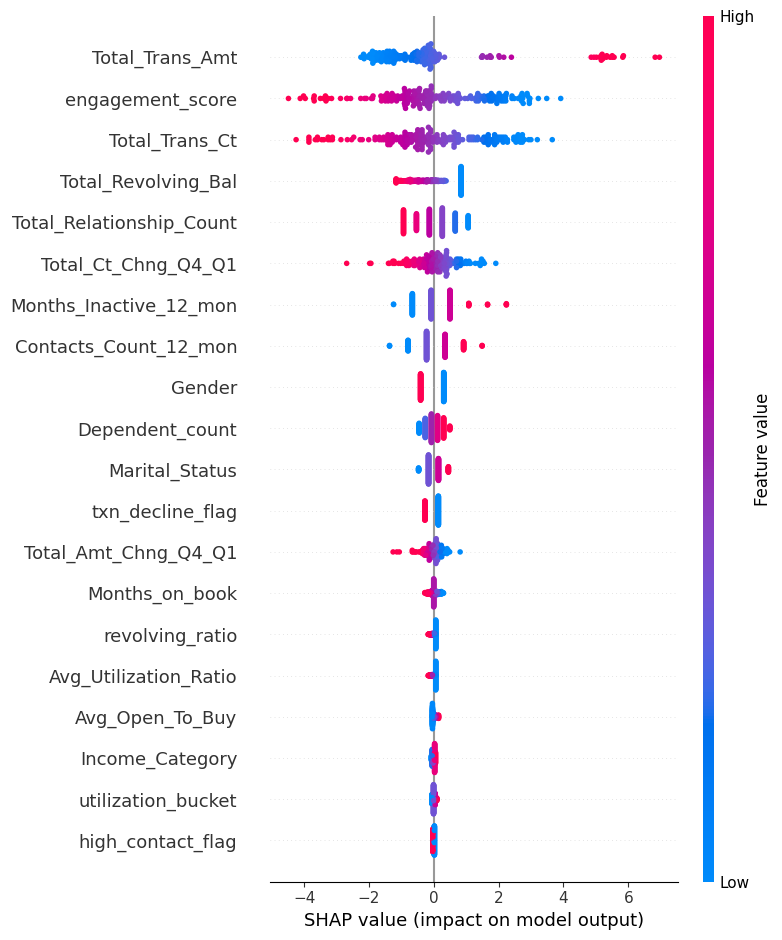

-- Random Forest --


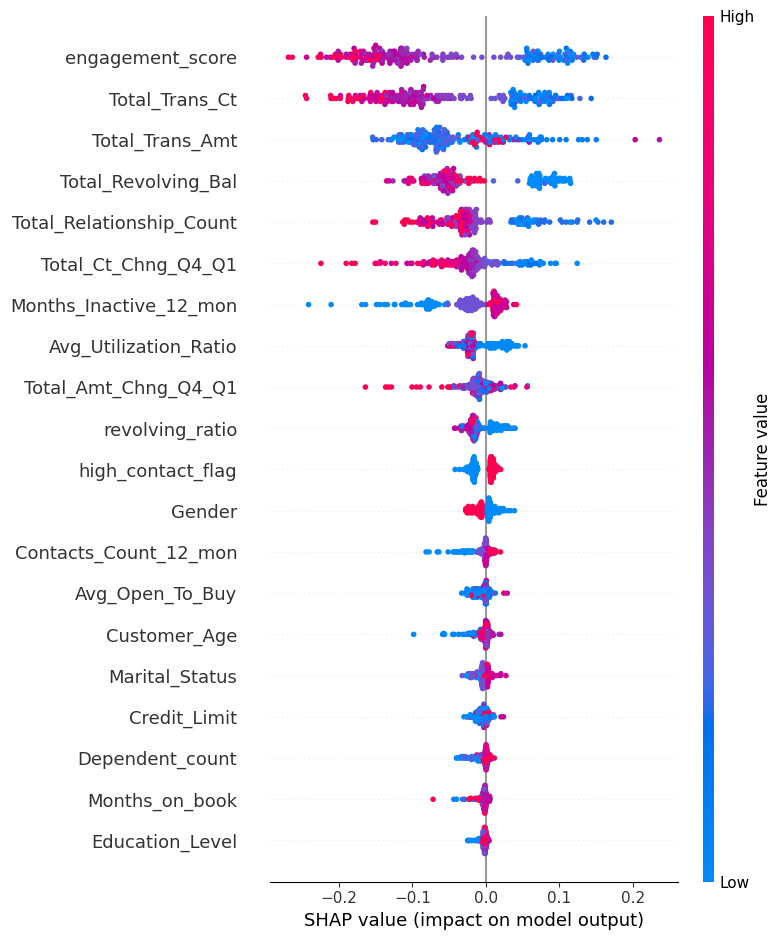

-- XGBoost --


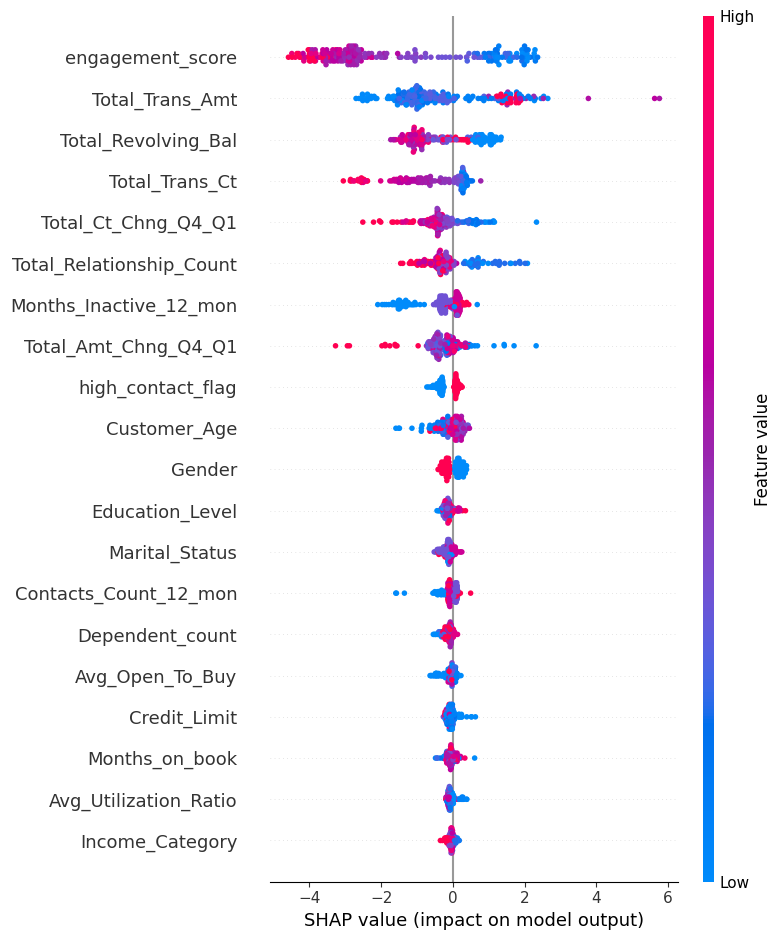

In [57]:
print("-- Logistic Regression --")
shap.summary_plot(sv_lr_2d, X_shap_sample, show=True)

print("-- Random Forest --")
shap.summary_plot(sv_rf_2d, X_shap_sample, show=True)

print("-- XGBoost --")
shap.summary_plot(sv_xgb_2d, X_shap_sample, feature_names=FEATURES, show=True)

### Waterfall Single At-Risk Customer

At-risk customer index: 102

-- Logistic Regression --


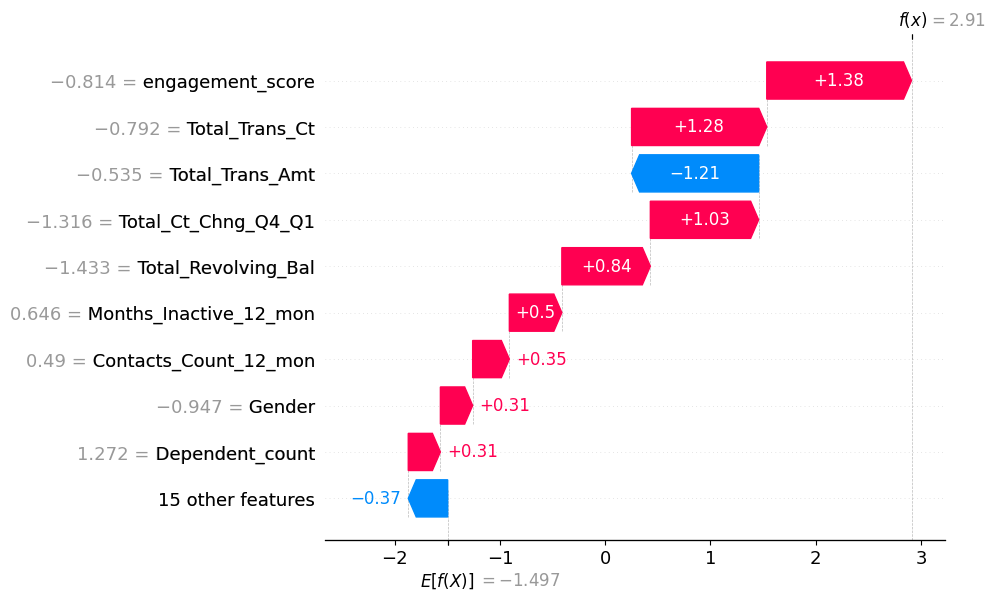


-- Random Forest --


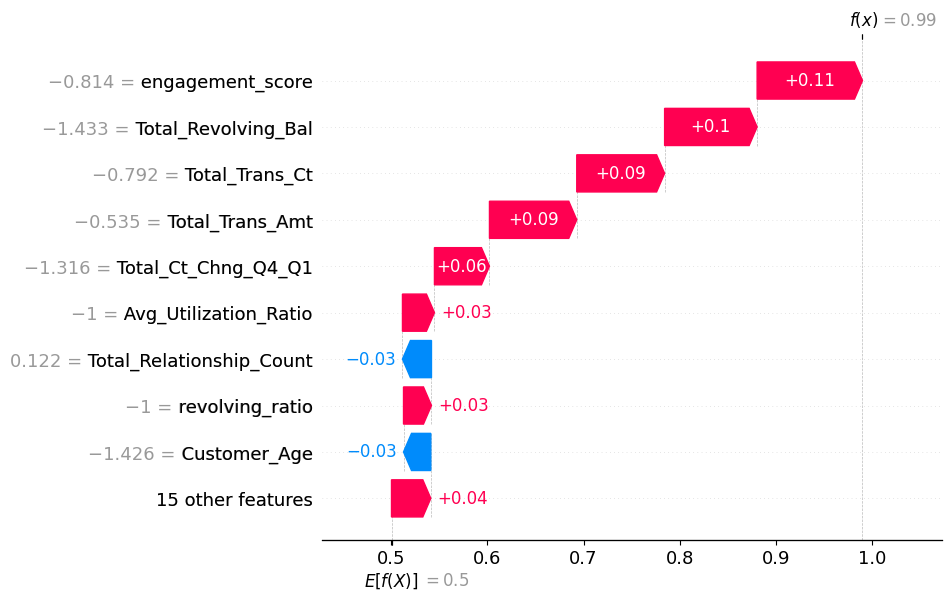


-- XGBoost --


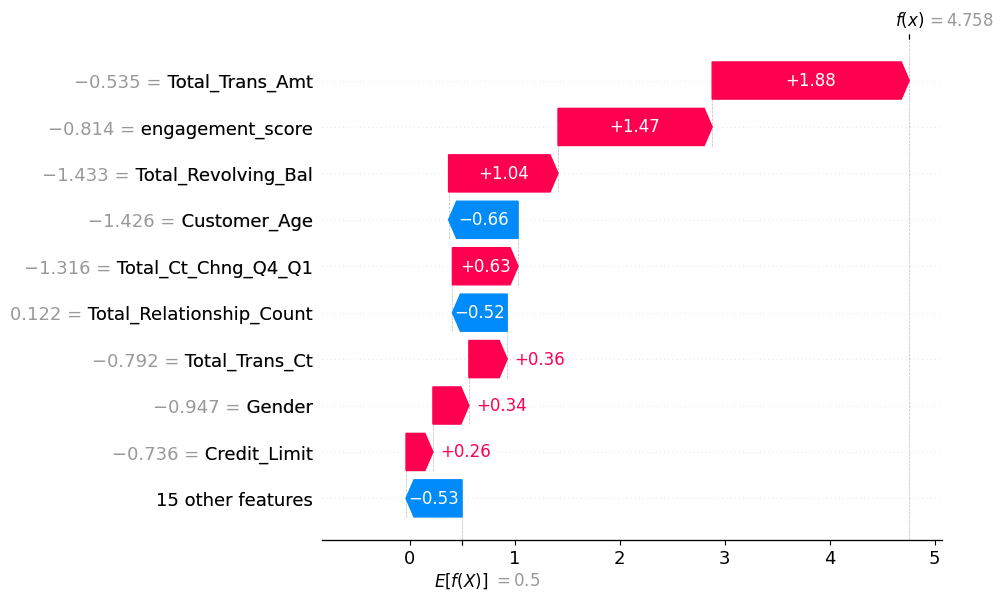

In [58]:
high_risk_idx = rf.predict_proba(X_shap_sample)[:, 1].argmax()
print(f"At-risk customer index: {high_risk_idx}")

# LR base value
lr_base = explainer_lr.expected_value
if isinstance(lr_base, (list, np.ndarray)):
    lr_base = float(lr_base[0])

# RF base value
rf_base = explainer_rf.expected_value
if isinstance(rf_base, (list, np.ndarray)):
    rf_base = float(rf_base[1])

print("\n-- Logistic Regression --")
shap.waterfall_plot(shap.Explanation(
    values        = sv_lr_2d[high_risk_idx],
    base_values   = lr_base,
    data          = X_shap_sample.iloc[high_risk_idx],
    feature_names = FEATURES
))

print("\n-- Random Forest --")
shap.waterfall_plot(shap.Explanation(
    values        = sv_rf_2d[high_risk_idx],
    base_values   = rf_base,
    data          = X_shap_sample.iloc[high_risk_idx],
    feature_names = FEATURES
))

print("\n-- XGBoost --")
shap.waterfall_plot(shap.Explanation(
    values        = sv_xgb_2d[high_risk_idx],
    base_values   = float(xgb_booster.attr('base_score') or 0.5),
    data          = X_shap_sample.iloc[high_risk_idx],
    feature_names = FEATURES
))

### Comparison Table

In [59]:
lr_imp  = pd.Series(np.abs(sv_lr_2d).mean(axis=0),  index=FEATURES)
rf_imp  = pd.Series(np.abs(sv_rf_2d).mean(axis=0),  index=FEATURES)
xgb_imp = pd.Series(np.abs(sv_xgb_2d).mean(axis=0), index=FEATURES)

comparison = pd.DataFrame({
    'Logistic Regression' : lr_imp,
    'Random Forest'       : rf_imp,
    'XGBoost'             : xgb_imp
}).sort_values('XGBoost', ascending=False).head(10).round(4)

print("-- Top 10 Features — SHAP Comparison --")
print(comparison)

-- Top 10 Features — SHAP Comparison --
                          Logistic Regression  Random Forest  XGBoost
engagement_score                       1.3741         0.1196   2.3895
Total_Trans_Amt                        1.3797         0.0662   1.2757
Total_Revolving_Bal                    0.5823         0.0647   0.8638
Total_Trans_Ct                         1.3169         0.0978   0.8267
Total_Ct_Chng_Q4_Q1                    0.4829         0.0430   0.5312
Total_Relationship_Count               0.5391         0.0496   0.5288
Months_Inactive_12_mon                 0.4795         0.0386   0.5066
Total_Amt_Chng_Q4_Q1                   0.1904         0.0184   0.4318
high_contact_flag                      0.0209         0.0139   0.2484
Customer_Age                           0.0048         0.0073   0.2409


## Block 10 - Business Impact Report

### Business Impact Report

In [60]:
print("=" * 55)
print("         BUSINESS IMPACT REPORT")
print("=" * 55)

total_customers   = len(y_test)
actual_churners   = y_test.sum()
true_positives    = ((xgb_preds == 1) & (y_test == 1)).sum()
false_negatives   = ((xgb_preds == 0) & (y_test == 1)).sum()
false_positives   = ((xgb_preds == 1) & (y_test == 0)).sum()

print(f"\nTest Set Summary")
print(f"  Total customers evaluated : {total_customers}")
print(f"  Actual churners           : {actual_churners}")
print(f"  Correctly identified      : {true_positives}")
print(f"  Missed churners           : {false_negatives}")
print(f"  False alarms              : {false_positives}")

         BUSINESS IMPACT REPORT

Test Set Summary
  Total customers evaluated : 2026
  Actual churners           : 325
  Correctly identified      : 287
  Missed churners           : 38
  False alarms              : 27


###  Financial Impact

In [61]:
avg_revenue_per_customer = 15000   # ₹ annual revenue per customer
retention_cost           = 2000    # ₹ cost to retain one customer

revenue_saved    = true_positives * avg_revenue_per_customer
retention_spend  = true_positives * retention_cost
net_impact       = revenue_saved - retention_spend
missed_revenue   = false_negatives * avg_revenue_per_customer
wasted_spend     = false_positives * retention_cost

print("=" * 55)
print("  FINANCIAL IMPACT (₹)")
print("=" * 55)
print(f"  Revenue protected         : ₹{revenue_saved:,.0f}")
print(f"  Retention campaign cost   : ₹{retention_spend:,.0f}")
print(f"  Net business value        : ₹{net_impact:,.0f}")
print(f"  Revenue at risk (missed)  : ₹{missed_revenue:,.0f}")
print(f"  Wasted spend (false alarm): ₹{wasted_spend:,.0f}")

  FINANCIAL IMPACT (₹)
  Revenue protected         : ₹4,305,000
  Retention campaign cost   : ₹574,000
  Net business value        : ₹3,731,000
  Revenue at risk (missed)  : ₹570,000
  Wasted spend (false alarm): ₹54,000


### Top Recommendations from SHAP

In [62]:
top_features = pd.Series(
    np.abs(sv_xgb_2d).mean(axis=0), index=FEATURES
).sort_values(ascending=False).head(3)

print("=" * 55)
print("  TOP 3 BUSINESS RECOMMENDATIONS")
print("=" * 55)
print(f"\n  Based on SHAP top features: {list(top_features.index)}")
print()
print("  1. Customers with Total_Trans_Ct < 40")
print("     → Proactive outreach with personalised offers")
print()
print("  2. Customers with Months_Inactive_12_mon >= 3")
print("     → Re-engagement campaign within 30 days")
print()
print("  3. Customers with Contacts_Count_12_mon >= 3")
print("     → Service quality review + priority support")

  TOP 3 BUSINESS RECOMMENDATIONS

  Based on SHAP top features: ['engagement_score', 'Total_Trans_Amt', 'Total_Revolving_Bal']

  1. Customers with Total_Trans_Ct < 40
     → Proactive outreach with personalised offers

  2. Customers with Months_Inactive_12_mon >= 3
     → Re-engagement campaign within 30 days

  3. Customers with Contacts_Count_12_mon >= 3
     → Service quality review + priority support


###  Final Model Summary

In [63]:
print("=" * 55)
print("  FINAL MODEL SUMMARY")
print("=" * 55)
print(f"  Model         : XGBoost")
print(f"  F1 Score      : {f1_score(y_test, xgb_preds):.3f}")
print(f"  AUC           : {roc_auc_score(y_test, xgb_proba):.3f}")
print(f"  Precision     : {precision_score(y_test, xgb_preds):.3f}")
print(f"  Recall        : {recall_score(y_test, xgb_preds):.3f}")
print(f"  Accuracy      : {(xgb_preds == y_test).mean()*100:.1f}%")
print()
print("  Models saved  → models/churn_model.pkl")
print("  Scaler saved  → models/scaler.pkl")
print("  Features saved→ models/feature_names.pkl")
print()
print("  Pipeline complete. Ready for deployment.")
print("=" * 55)

  FINAL MODEL SUMMARY
  Model         : XGBoost
  F1 Score      : 0.898
  AUC           : 0.992
  Precision     : 0.914
  Recall        : 0.883
  Accuracy      : 96.8%

  Models saved  → models/churn_model.pkl
  Scaler saved  → models/scaler.pkl
  Features saved→ models/feature_names.pkl

  Pipeline complete. Ready for deployment.
